# Exploitation de données électorales avec Python

Antoine Rustenholz, Aziz Seghaier, Jasmin Neveu
31.04.2026

In [ ]:
import pandas as pd
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/tmp/ipykernel_86386/192654150.py:2: DtypeWarning: Columns (0: prenom) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## 1. Explorations générales

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 1
</div>
</div>
<div class="callout-body-container callout-body">

Créer ou mettre à jour les variables suivantes:

-   `code_commune`: En utilisant la variable déjà existante et le département, remplacer la valeur `code_commune` pour constituer un vrai code commune. Par exemple, pour Montrouge, vous devriez obtenir 92049.

-   `candidat`: créer une colonne avec le prenom et le nom mis ensemble, en n’oubliant pas de mettre un espace. Ne pas éliminer les bulletins abstentions, blancs ou nuls, nous allons les exploiter ultérieurement.

</div>
</div>

In [3]:
# Pour créer un vrai code commune, il suffit de concaténer les codes du départements et de la commune
# en ajoutant des zéros afin d'avoir toujours un code à 5 chiffres.
df['code_commune'] = (
    df['code_departement'].astype(str).str.zfill(2) +
    df['code_commune'].astype(str).str.zfill(3)
)

# On fait juste attentionau valeurs manquantes dans la colonne prenom pour les votes non exprimés.
df['candidat'] = (
    df['prenom'].fillna('') + ' ' + df['nom']
)

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 2
</div>
</div>
<div class="callout-body-container callout-body">

Compléter la phrase suivante grâce à Python:
En 2022, il y avait XXXXX candidats à l’élection présidentielle.
*Note: Attention aux votes non exprimés et aux abstentions*

</div>
</div>

In [4]:
# Il suffit de compter le nombre de valeurs différentes pour candidats en supprimant les abstentions, les votes blancs et nuls.
f"En 2022, il y avait {df['candidat'].nunique()-3} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 3
</div>
</div>
<div class="callout-body-container callout-body">

Calculer les scores nationaux de chaque candidat. Représenter dans ce tableau, pour chaque candidat, le nombre de voix et le pourcatage des votes exprimés (c’est-à-dire en retirant abstentions et votes non exprimés).
Représenter cela dans un *dataframe* ou, pour avoir tous les points, dans un tableau mis en forme via `great_tables` (il n’est pas obligatoire d’aller aussi loin dans la mise en forme mais essayez d’obtenir un beau tableau tout de même).
*Note: vous pouvez contrôler vos résultats obtenus avec cette page.*

</div>
</div>

In [5]:
# Création d'une table auxiliaire
resultats = (
    df[['candidat', 'voix']]
    .groupby('candidat', as_index = False).sum()
)

# Suppression des non-candidats
resultats = resultats[~resultats['candidat'].isin([' abstentions', ' nuls', ' blancs'])]

# Calcul du nombre total de voix exprimées
nombre_total = resultats['voix'].sum()

# Création de la variable score
resultats['score'] = resultats['voix'] / nombre_total

# Tri
resultats = resultats.sort_values('voix', ascending=False)


# Génération du tableau
from great_tables import GT

(
    GT(resultats)
    .tab_header(
        title = "Elections présidentielles 2022",
        subtitle = "Résultats du premier tour (10 avril 2022)"
    )
    .cols_label( # Renommage des colonnes
        candidat = "Candidat",
        voix = "Nombre votes (total)",
        score = "Score (% votes exprimés)"
    )
    .fmt_number( # Formatage des nombres de voix
        columns = "voix",
        decimals = 0,
        sep_mark = ' '
    )
    .fmt_percent( # Formatage du score en pourcentage
        columns = "score",
        decimals = 2
    )
)

GT(_tbl_data=                 candidat     voix     score
4         Emmanuel MACRON  9783058  0.278458
8           Marine LE PEN  8133828  0.231516
7      Jean-Luc MÉLENCHON  7712520  0.219524
14           Éric ZEMMOUR  2485226  0.070738
12       Valérie PÉCRESSE  1679001  0.047790
13          Yannick JADOT  1627853  0.046334
6           Jean LASSALLE  1101387  0.031349
5          Fabien ROUSSEL   802422  0.022840
10  Nicolas DUPONT-AIGNAN   725176  0.020641
3            Anne HIDALGO   616478  0.017547
11        Philippe POUTOU   268904  0.007654
9        Nathalie ARTHAUD   197094  0.005610, _body=<great_tables._gt_data.Body object at 0x7f6d95bff380>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f6d95bff0e0>, _spanners=Spanners([]), _heading=Heading(title='Elections présidentielles 2022', subtitle='Résultats du premier tour (10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f6d95bff770>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f6d95bf3750>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f6d95bff8c0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f6d95bff620>, <great_tables._gt_data.FormatInfo object at 0x7f6d95bf3610>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_

## 2. Comparaison des scores départements aux moyennes nationales.

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 4
</div>
</div>
<div class="callout-body-container callout-body">

Créer un *dataframe* nommé `score_departements` stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).

</div>
</div>

In [30]:

df_exprimes = df[~df['candidat'].isin([' abstentions', ' nuls', ' blancs'])].copy()
votes_par_dept = (
    df_exprimes
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
)
score_departements = votes_par_dept.copy()
score_departements = score_departements.rename(columns={'voix': 'votes_departements'})
total_par_dept = (
    score_departements
    .groupby('code_departement')['votes_departements']
    .transform('sum')
)
score_departements['score_departement'] = (
    score_departements['votes_departements'] / total_par_dept
)

score_departements_display = score_departements.copy()
score_departements_display = score_departements_display.rename(columns={
    'code_departement': 'Département',
    'candidat': 'Candidat',
    'votes_departements': 'Voix département',
    'score_departement': 'Score (%)'
})
(
    GT(score_departements_display.head(20))
    .tab_header(
        title="Scores par département",
        subtitle="Premier tour 2022"
    )
    .fmt_number(
        columns="Voix département",
        decimals=0,
        sep_mark=' '
    )
    .fmt_percent(
        columns="Score (%)",
        decimals=2
    )
)



GT(_tbl_data=   Département               Candidat  Voix département  Score (%)
0           01           Anne HIDALGO              5644   0.016948
1           01        Emmanuel MACRON             92206   0.276875
2           01         Fabien ROUSSEL              5938   0.017831
3           01          Jean LASSALLE             10876   0.032658
4           01     Jean-Luc MÉLENCHON             57832   0.173657
5           01          Marine LE PEN             86755   0.260507
6           01       Nathalie ARTHAUD              1658   0.004979
7           01  Nicolas DUPONT-AIGNAN              8998   0.027019
8           01        Philippe POUTOU              2172   0.006522
9           01       Valérie PÉCRESSE             17572   0.052765
10          01          Yannick JADOT             15843   0.047573
11          01           Éric ZEMMOUR             27530   0.082667
12          02           Anne HIDALGO              2983   0.011220
13          02        Emmanuel MACRON             58721   0.220872
14          02         Fabien ROUSSEL              5968   0.022448
15          02          Jean LASSALLE              6468   0.024329
16          02     Jean-Luc MÉLENCHON             41172   0.154863
17          02          Marine LE PEN            104342   0.392470
18          02       Nathalie ARTHAUD              2038   0.007666
19          02  Nicolas DUPONT-AIGNAN              5790   0.021778, _body=<great_tables._gt_data.Body object at 0x7f6d90a72120>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Voix département', type=<ColInfoTypeEnum.default: 1>, column_label='Voix département', column_align='right', column_width=None), ColInfo(var='Score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f6d7fac9710>, _spanners=Spanners([]), _heading=Heading(title='Scores par département', subtitle='Premier tour 2022', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f6d7faf10d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f6d7faf0b30>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f6d7fac92b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f6d7faa0cd0>, <great_tables._gt_data.FormatInfo object at 0x7f6d7fca09d0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True,

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 5
</div>
</div>
<div class="callout-body-container callout-body">

Refaire le lien avec le niveau national pour comparer le score départemental avec le score national. Nommer ce *dataframe* `score_departements`, nous allons le réutiliser par la suite.

</div>
</div>

In [31]:
candidats_liste = df_exprimes['candidat'].unique().tolist()
votes_nationaux = (
    df_exprimes
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_nationales'})
)
total_national = votes_nationaux['votes_nationales'].sum()
votes_nationaux['score_national'] = votes_nationaux['votes_nationales'] / total_national
score_departements = score_departements.merge(
    votes_nationaux[['candidat', 'votes_nationales', 'score_national']],
    on='candidat',
    how='left'
)
score_departements_display = score_departements.rename(columns={
    'code_departement': 'Département',
    'candidat': 'Candidat',
    'votes_departements': 'Voix département',
    'score_departement': 'Score (%)',
    'votes_nationales': 'Voix nationales',
    'score_national': 'Score national (%)'
})
(
    GT(score_departements_display.head(20))
    .tab_header(
        title="Scores départementaux vs nationaux",
        subtitle="Premier tour 2022"
    )
    .fmt_number(
        columns=["Voix département", "Voix nationales"],
        decimals=0,
        sep_mark=' '
    )
    .fmt_percent(
        columns=["Score (%)", "Score national (%)"],
        decimals=2
    )
)


GT(_tbl_data=   Département               Candidat  Voix département  Score (%)  \
0           01           Anne HIDALGO              5644   0.016948   
1           01        Emmanuel MACRON             92206   0.276875   
2           01         Fabien ROUSSEL              5938   0.017831   
3           01          Jean LASSALLE             10876   0.032658   
4           01     Jean-Luc MÉLENCHON             57832   0.173657   
5           01          Marine LE PEN             86755   0.260507   
6           01       Nathalie ARTHAUD              1658   0.004979   
7           01  Nicolas DUPONT-AIGNAN              8998   0.027019   
8           01        Philippe POUTOU              2172   0.006522   
9           01       Valérie PÉCRESSE             17572   0.052765   
10          01          Yannick JADOT             15843   0.047573   
11          01           Éric ZEMMOUR             27530   0.082667   
12          02           Anne HIDALGO              2983   0.011220   
13          02        Emmanuel MACRON             58721   0.220872   
14          02         Fabien ROUSSEL              5968   0.022448   
15          02          Jean LASSALLE              6468   0.024329   
16          02     Jean-Luc MÉLENCHON             41172   0.154863   
17          02          Marine LE PEN            104342   0.392470   
18          02       Nathalie ARTHAUD              2038   0.007666   
19          02  Nicolas DUPONT-AIGNAN              5790   0.021778   

    Voix nationales  Score national (%)  
0            616478            0.017547  
1           9783058            0.278458  
2            802422            0.022840  
3           1101387            0.031349  
4           7712520            0.219524  
5           8133828            0.231516  
6            197094            0.005610  
7            725176            0.020641  
8            268904            0.007654  
9           1679001            0.047790  
10          1627853            0.046334  
11          2485226            0.070738  
12           616478            0.017547  
13          9783058            0.278458  
14           802422            0.022840  
15          1101387            0.031349  
16          7712520            0.219524  
17          8133828            0.231516  
18           197094            0.005610  
19           725176            0.020641  , _body=<great_tables._gt_data.Body object at 0x7f6d90a6adf0>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Voix département', type=<ColInfoTypeEnum.default: 1>, column_label='Voix département', column_align='right', column_width=None), ColInfo(var='Score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None), ColInfo(var='Voix nationales', type=<ColInfoTypeEnum.default: 1>, column_label='Voix nationales', column_align='right', column_width=None), ColInfo(var='Score national (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score national (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f6d90aa47a0>, _spanners=Spanners([]), _heading=Heading(title='Scores départementaux vs nationaux', subtitle='Premier tour 2022', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f6d7faf35f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f6d7faf0a70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f6d90aa4940>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f6d7fca2ea0>, <great_tables._gt_data.FormatInfo object at 0x7f6d95b03bf0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), 

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 6
</div>
</div>
<div class="callout-body-container callout-body">

Créer une variable `surrepresentation` qui compare, en relatif, les scores nationaux et départementaux.
Par exemple, si un candidat a un score de 30% dans un département mais de 15% ailleurs, la valeur de `surrepresentation` sera égale à 100 (%).


</div>
</div>

In [33]:
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national'] * 100
)
score_departements_display = score_departements.rename(columns={
    'code_departement': 'Département',
    'candidat': 'Candidat',
    'votes_departements': 'Voix département',
    'score_departement': 'Score (%)',
    'votes_nationales': 'Voix nationales',
    'score_national': 'Score national (%)',
    'surrepresentation': 'Surrépresentation (%)'
})
(
    GT(score_departements_display.head(20))
    .tab_header(
        title="Surrépresentation par département",
        subtitle="Écart relatif au score national (%) - Premier tour 2022"
    )
    .fmt_number(
        columns=["Voix département", "Voix nationales"],
        decimals=0,
        sep_mark=' '
    )
    .fmt_percent(
        columns=["Score (%)", "Score national (%)"],
        decimals=2
    )
    .fmt_number(
        columns="Surrépresentation (%)",
        decimals=1,
        sep_mark=' '
    )
)

GT(_tbl_data=   Département               Candidat  Voix département  Score (%)  \
0           01           Anne HIDALGO              5644   0.016948   
1           01        Emmanuel MACRON             92206   0.276875   
2           01         Fabien ROUSSEL              5938   0.017831   
3           01          Jean LASSALLE             10876   0.032658   
4           01     Jean-Luc MÉLENCHON             57832   0.173657   
5           01          Marine LE PEN             86755   0.260507   
6           01       Nathalie ARTHAUD              1658   0.004979   
7           01  Nicolas DUPONT-AIGNAN              8998   0.027019   
8           01        Philippe POUTOU              2172   0.006522   
9           01       Valérie PÉCRESSE             17572   0.052765   
10          01          Yannick JADOT             15843   0.047573   
11          01           Éric ZEMMOUR             27530   0.082667   
12          02           Anne HIDALGO              2983   0.011220   
13          02        Emmanuel MACRON             58721   0.220872   
14          02         Fabien ROUSSEL              5968   0.022448   
15          02          Jean LASSALLE              6468   0.024329   
16          02     Jean-Luc MÉLENCHON             41172   0.154863   
17          02          Marine LE PEN            104342   0.392470   
18          02       Nathalie ARTHAUD              2038   0.007666   
19          02  Nicolas DUPONT-AIGNAN              5790   0.021778   

    Voix nationales  Score national (%)  Surrépresentation (%)  
0            616478            0.017547              -3.415270  
1           9783058            0.278458              -0.568589  
2            802422            0.022840             -21.931396  
3           1101387            0.031349               4.176149  
4           7712520            0.219524             -20.893721  
5           8133828            0.231516              12.522294  
6            197094            0.005610             -11.253717  
7            725176            0.020641              30.900593  
8            268904            0.007654             -14.787834  
9           1679001            0.047790              10.410223  
10          1627853            0.046334               2.674190  
11          2485226            0.070738              16.863630  
12           616478            0.017547             -36.056375  
13          9783058            0.278458             -20.680422  
14           802422            0.022840              -1.714926  
15          1101387            0.031349             -22.394653  
16          7712520            0.219524             -29.454837  
17          8133828            0.231516              69.521877  
18           197094            0.005610              36.644563  
19           725176            0.020641               5.510753  , _body=<great_tables._gt_data.Body object at 0x7f6d7ef2b8e0>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Voix département', type=<ColInfoTypeEnum.default: 1>, column_label='Voix département', column_align='right', column_width=None), ColInfo(var='Score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None), ColInfo(var='Voix nationales', type=<ColInfoTypeEnum.default: 1>, column_label='Voix nationales', column_align='right', column_width=None), ColInfo(var='Score national (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score national (%)', column_align='right', column_width=None), ColInfo(var='Surrépresentation (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Surrépresentation (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f6d7f08f590>, _spanners=Spanners([]), _heading=Heading(ti

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 7
</div>
</div>
<div class="callout-body-container callout-body">

Créer une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des
principales surreprésentations (en valeur absolue) par département.

</div>
</div>

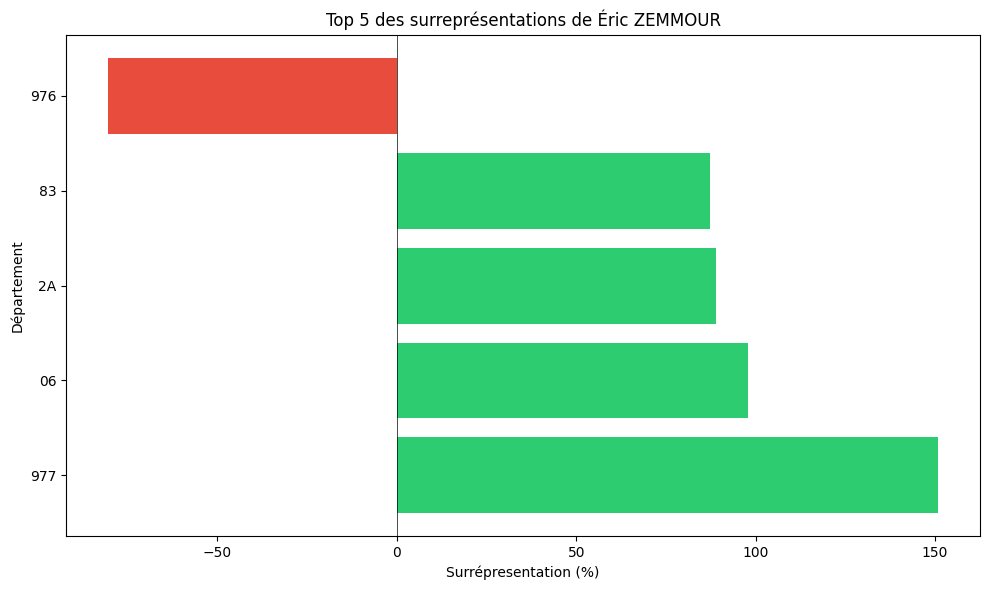

In [35]:
import matplotlib.pyplot as plt
def plot_surrepresentation(candidat, n=5):
    df_candidat = score_departements[score_departements['candidat'] == candidat].copy()
    df_candidat = df_candidat.sort_values('surrepresentation', key=abs, ascending=False).head(n)
    
    plt.figure(figsize=(10, 6))
    colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_candidat['surrepresentation']]
    
    plt.barh(df_candidat['code_departement'], df_candidat['surrepresentation'], color=colors)
    plt.xlabel('Surrépresentation (%)')
    plt.ylabel('Département')
    plt.title(f'Top {n} des surreprésentations de {candidat}')
    plt.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()
# Exemple avec Éric ZEMMOUR
plot_surrepresentation('Éric ZEMMOUR')

## 3. Un peu de cartographie

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 8
</div>
</div>
<div class="callout-body-container callout-body">

Faire une fonction permettant de restreindre `score_departements` en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser `score_departements` nous allons l’utiliser à nouveau !).
Faire une jointure au fond de carte des départements et effectuer une carte de la représentation.

</div>
</div>